### Importações das bibliotecas

In [ ]:
import numpy as np
import time
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

### Carregando dados do Google Drive

In [2]:
# Monte seu Google Drive
from google.colab import drive
drive.mount('/content/drive')

print('Google Drive montado com sucesso!')

Mounted at /content/drive
Google Drive montado com sucesso!


### Test // Traing

In [3]:
# Faça upload pelo painel lateral do Colab antes de rodar
TRAIN_PATH = '/content/drive/MyDrive/Colab Notebooks/BASE DE DADOS/digits.train'
TEST_PATH  = '/content/drive/MyDrive/Colab Notebooks/BASE DE DADOS/digits.test'

def load_data(path):
    data = np.loadtxt(path)           # leitura vetorizada completa
    y    = data[:, 0].astype(int)    # col 0 = rótulo
    X    = data[:, 1:]               # demais cols = features
    return X, y

X_train, y_train = load_data(TRAIN_PATH)
X_test,  y_test  = load_data(TEST_PATH)

print(f'Treino : {X_train.shape}  | classes: {np.unique(y_train)}')
print(f'Teste  : {X_test.shape}   | classes: {np.unique(y_test)}')
print(f'Dist. treino: {dict(sorted(Counter(y_train).items()))}')

Treino : (7291, 2)  | classes: [0 1 2 3 4 5 6 7 8 9]
Teste  : (2007, 2)   | classes: [0 1 2 3 4 5 6 7 8 9]
Dist. treino: {np.int64(0): 1194, np.int64(1): 1005, np.int64(2): 731, np.int64(3): 658, np.int64(4): 652, np.int64(5): 556, np.int64(6): 664, np.int64(7): 645, np.int64(8): 542, np.int64(9): 644}


### Pré processamento dos dados

In [4]:
def normalize(X_tr, X_te):
    mu  = X_tr.mean(axis=0)
    std = X_tr.std(axis=0) + 1e-8   # evita divisão por zero
    return (X_tr - mu) / std, (X_te - mu) / std

def add_bias(X):
    return np.hstack([np.ones((X.shape[0], 1)), X])

X_train_n, X_test_n = normalize(X_train, X_test)
X_train_b = add_bias(X_train_n)   # (N_train, D+1)
X_test_b  = add_bias(X_test_n)    # (N_test,  D+1)

print(f'Shape - bias: treino={X_train_b.shape}, teste={X_test_b.shape}')

Shape - bias: treino=(7291, 3), teste=(2007, 3)


### Pocket PLA

In [5]:
def pocket_pla(X, y_binary, max_iter=2000, seed=42):
    rng  = np.random.default_rng(seed)
    N, D = X.shape

    w     = np.zeros(D)             # inicialização em zero
    preds = np.sign(X @ w)
    preds[preds == 0] = 1           # desempate → +1

    best_w   = w.copy()
    best_acc = np.mean(preds == y_binary)

    for _ in range(max_iter):
        # operação vetorizada
        wrong = np.where(preds != y_binary)[0]
        if len(wrong) == 0:
            break                    # convergiu (dados separáveis)

        i = rng.choice(wrong)       # pega um errado aleatório

        # ── atualização do Perceptron
        w = w + y_binary[i] * X[i]

        # re-calcula predições e acurácia
        preds = np.sign(X @ w)
        preds[preds == 0] = 1
        acc = np.mean(preds == y_binary)

        # ── pocket: guarda o melhor
        if acc > best_acc:
            best_acc = acc
            best_w   = w.copy()

    return best_w

### Treino

In [6]:
# Perceptron dígito (0–9)
CLASSES  = np.unique(y_train)
MAX_ITER = 2000

weights = {}   # vetor de pesos da classe k

print('Treinando Pocket PLA (One-vs-All)...')
t0 = time.time()

for k in CLASSES:
    # +1 para dígito k, -1 para todos os outros
    y_bin      = np.where(y_train == k, 1, -1)
    weights[k] = pocket_pla(X_train_b, y_bin,
                              max_iter=MAX_ITER, seed=int(k))
    print(f'  Classe {k} ✓')

print(f'\nConcluído em {time.time()-t0:.1f}s')

Treinando Pocket PLA (One-vs-All)...
  Classe 0 ✓
  Classe 1 ✓
  Classe 2 ✓
  Classe 3 ✓
  Classe 4 ✓
  Classe 5 ✓
  Classe 6 ✓
  Classe 7 ✓
  Classe 8 ✓
  Classe 9 ✓

Concluído em 3.0s


### Predição

In [1]:
def predict_multiclass(X, weights, classes):
    # empilha pesos → W shape (K, D+1)
    W      = np.vstack([weights[k] for k in classes])
    scores = X @ W.T                          # (N, K)
    best   = np.argmax(scores, axis=1)       # índice da maior coluna
    return classes[best]

y_pred_train = predict_multiclass(X_train_b, weights, CLASSES)
y_pred_test  = predict_multiclass(X_test_b,  weights, CLASSES)

NameError: name 'X_train_b' is not defined

### Avaliação

In [8]:
def error_rate(y_true, y_pred):
    return np.mean(y_true != y_pred)

E_in  = error_rate(y_train, y_pred_train)
E_out = error_rate(y_test,  y_pred_test)

print('='*46)
print(f'  Erro na amostra     (E_in)  : {E_in:.4f}  ({E_in*100:.2f}%)')
print(f'  Erro fora da amostra(E_out) : {E_out:.4f}  ({E_out*100:.2f}%)')
print(f'  Acurácia treino              : {(1-E_in)*100:.2f}%')
print(f'  Acurácia teste               : {(1-E_out)*100:.2f}%')
print('='*46)

# detalhe por classe
print(f'\n{"Classe":>6} | {"Acurácia Treino":>15} | {"Acurácia Teste":>14}')
print('-'*42)
for k in CLASSES:
    mask_tr = y_train == k
    mask_te = y_test  == k
    acc_tr  = np.mean(y_pred_train[mask_tr] == k)
    acc_te  = np.mean(y_pred_test[mask_te]  == k)
    print(f'{k:>6} | {acc_tr*100:>14.2f}% | {acc_te*100:>13.2f}%')

  Erro na amostra     (E_in)  : 0.6501  (65.01%)
  Erro fora da amostra(E_out) : 0.6547  (65.47%)
  Acurácia treino              : 34.99%
  Acurácia teste               : 34.53%

Classe | Acurácia Treino | Acurácia Teste
------------------------------------------
     0 |          61.89% |         69.08%
     1 |          96.12% |         89.02%
     2 |           0.00% |          0.00%
     3 |           0.00% |          0.00%
     4 |          31.13% |         26.00%
     5 |          14.03% |         11.88%
     6 |          53.77% |         59.41%
     7 |          32.25% |         25.85%
     8 |           0.00% |          0.00%
     9 |           0.00% |          0.00%


### Configuração de matriz

In [9]:
def confusion_matrix_np(y_true, y_pred, classes):
    K   = len(classes)
    idx = {c: i for i, c in enumerate(classes)}
    cm  = np.zeros((K, K), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[idx[t], idx[p]] += 1
    return cm

cm = confusion_matrix_np(y_test, y_pred_test, CLASSES)

print('\nMatriz de Confusão (teste) — linhas=real, colunas=predito')
header = '     ' + '  '.join(f'{c:3}' for c in CLASSES)
print(header)
for i, row in enumerate(cm):
    print(f'  {CLASSES[i]:2} |', '  '.join(f'{v:3}' for v in row))


Matriz de Confusão (teste) — linhas=real, colunas=predito
       0    1    2    3    4    5    6    7    8    9
   0 | 248    4    0    0    2    0  105    0    0    0
   1 |   4  235    0    0    5    0   18    2    0    0
   2 |  16    2    0    0   23   25  114   18    0    0
   3 |  35    1    0    0   18    7  104    1    0    0
   4 |   4    2    0    0   52   10   95   37    0    0
   5 |  15    0    0    0   24   19   90   10    2    0
   6 |   5    0    0    0   41   11  101   11    1    0
   7 |   2    2    0    0   51    8   46   38    0    0
   8 |  46    0    0    0   10    6  100    4    0    0
   9 |   5    0    0    0   52    4  102   14    0    0


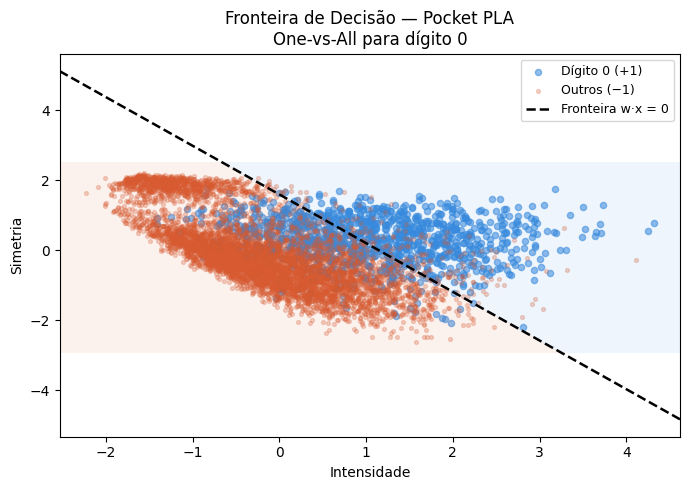

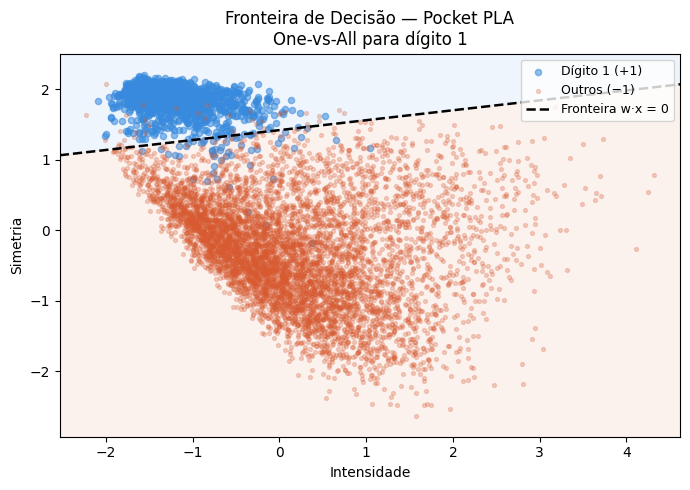

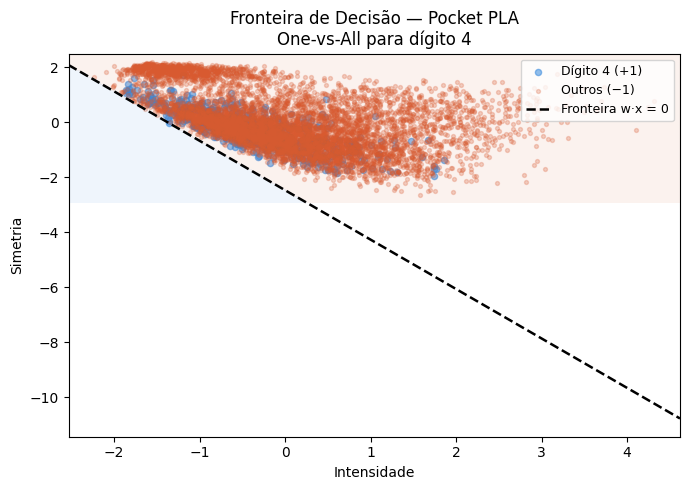

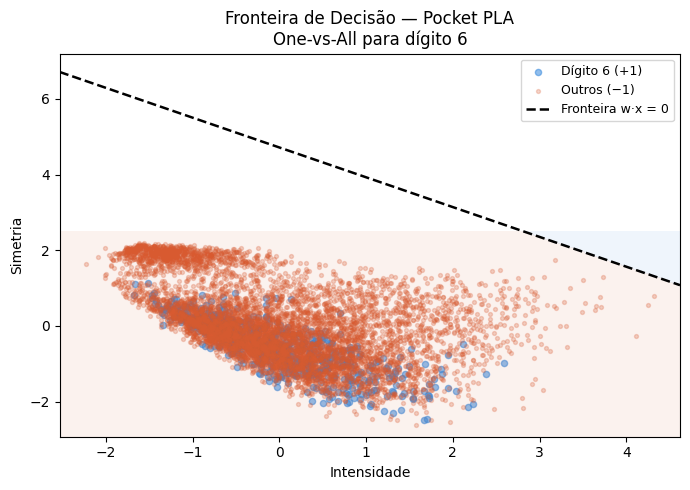

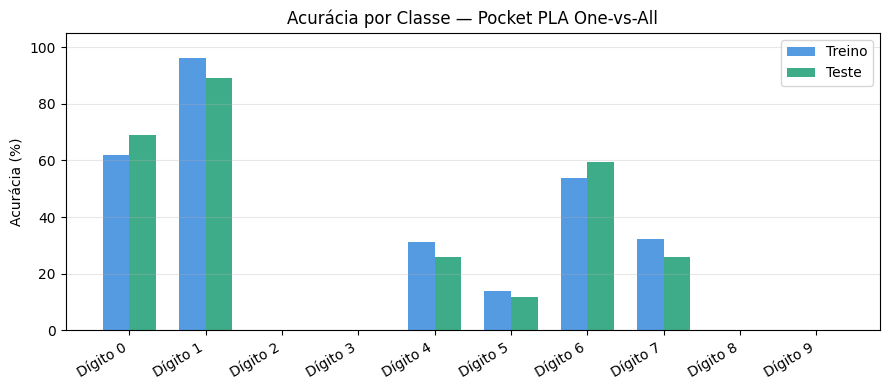

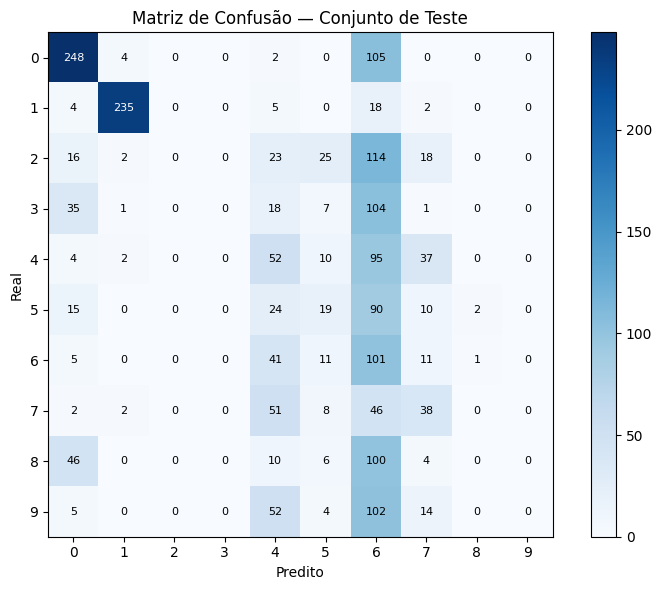

In [10]:
def plot_decision_boundary(X, y, weights, class_k, feature_names=('Intensidade', 'Simetria')):
    assert X.shape[1] == 3, "Use X com bias + 2 features"

    w = weights[class_k]          # [w0, w1, w2]
    y_bin = np.where(y == class_k, 1, -1)

    fig, ax = plt.subplots(figsize=(7, 5))

    # scatter dos pontos
    mask_pos = y_bin == 1
    mask_neg = y_bin == -1
    ax.scatter(X[mask_pos, 1], X[mask_pos, 2],
               c='#378ADD', s=20, alpha=0.55, label=f'Dígito {class_k} (+1)')
    ax.scatter(X[mask_neg, 1], X[mask_neg, 2],
               c='#D85A30', s=8, alpha=0.25, label='Outros (−1)')

    # fronteira de decisão: w0 + w1*x1 + w2*x2 = 0  →  x2 = -(w0 + w1*x1)/w2
    x1_min, x1_max = X[:, 1].min() - 0.3, X[:, 1].max() + 0.3
    x1_vals = np.linspace(x1_min, x1_max, 300)
    if abs(w[2]) > 1e-8:
        x2_vals = -(w[0] + w[1] * x1_vals) / w[2]
        ax.plot(x1_vals, x2_vals, 'k--', lw=1.8, label='Fronteira w·x = 0')

    # regiões coloridas (fundo)
    xx, yy = np.meshgrid(
        np.linspace(x1_min, x1_max, 200),
        np.linspace(X[:, 2].min() - 0.3, X[:, 2].max() + 0.3, 200)
    )
    bias_col = np.ones((xx.ravel().shape[0], 1))
    grid = np.hstack([bias_col, xx.ravel()[:, None], yy.ravel()[:, None]])
    scores = grid @ w
    zz = np.sign(scores).reshape(xx.shape)
    ax.contourf(xx, yy, zz, alpha=0.08,
                levels=[-2, 0, 2], colors=['#D85A30', '#378ADD'])

    ax.set_xlabel(feature_names[0]); ax.set_ylabel(feature_names[1])
    ax.set_title(f'Fronteira de Decisão — Pocket PLA\nOne-vs-All para dígito {class_k}')
    ax.legend(fontsize=9, loc='upper right')
    plt.tight_layout()
    plt.show()


# ── Chame para cada dígito desejado (exemplo: 0 e 1) ────────────────────────
for digit in [0, 1, 4, 6]:
    plot_decision_boundary(X_train_b, y_train, weights, digit)


# ── Gráfico de acurácia por classe ───────────────────────────────────────────
def plot_accuracy_by_class(y_train, y_pred_train, y_test, y_pred_test, classes):
    train_acc = [np.mean(y_pred_train[y_train == k] == k) * 100 for k in classes]
    test_acc  = [np.mean(y_pred_test [y_test  == k] == k) * 100 for k in classes]

    x = np.arange(len(classes)); w = 0.35
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar(x - w/2, train_acc, w, label='Treino',  color='#378ADD', alpha=0.85)
    ax.bar(x + w/2, test_acc,  w, label='Teste',   color='#1D9E75', alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels([f'Dígito {c}' for c in classes], rotation=30, ha='right')
    ax.set_ylabel('Acurácia (%)'); ax.set_ylim(0, 105)
    ax.set_title('Acurácia por Classe — Pocket PLA One-vs-All')
    ax.legend(); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()

plot_accuracy_by_class(y_train, y_pred_train, y_test, y_pred_test, CLASSES)


# ── Matriz de confusão como heatmap ─────────────────────────────────────────
def plot_confusion_heatmap(cm, classes):
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(len(classes))); ax.set_xticklabels(classes)
    ax.set_yticks(range(len(classes))); ax.set_yticklabels(classes)
    ax.set_xlabel('Predito'); ax.set_ylabel('Real')
    ax.set_title('Matriz de Confusão — Conjunto de Teste')
    thresh = cm.max() / 2
    for i in range(len(classes)):
        for j in range(len(classes)):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    fontsize=8, color='white' if cm[i, j] > thresh else 'black')
    plt.colorbar(im, ax=ax)
    plt.tight_layout(); plt.show()

cm = confusion_matrix_np(y_test, y_pred_test, CLASSES)
plot_confusion_heatmap(cm, CLASSES)